# **Importing Required Libraries**


In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler,LabelEncoder
from sklearn.model_selection import train_test_split, cross_validate
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

pd.set_option('display.max_columns', None)
pd.set_option('display.width', 500)
pd.set_option('display.float_format',  '{:.2f}'.format)

In [ ]:
df = pd.read_csv("/kaggle/input/heart-attack-analysis-prediction-dataset/heart.csv")
df_copy = df.copy()
df_copy.head()

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
0,63,1,3,145,233,1,0,150,0,2.30,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.50,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.40,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.80,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.60,2,0,2,1


<a id="section-one"></a>

# **EDA**


In [ ]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trtbps    303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalachh  303 non-null    int64  
 8   exng      303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slp       303 non-null    int64  
 11  caa       303 non-null    int64  
 12  thall     303 non-null    int64  
 13  output    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [ ]:
print(f'Shape     : {df_copy.shape}\n'
      f'Size      : {df_copy.size}\n'
      f'Dimension : {df_copy.ndim}')

Shape     : (303, 14)
Size      : 4242
Dimension : 2


In [ ]:
df_copy.isnull().sum()

age         0
sex         0
cp          0
trtbps      0
chol        0
fbs         0
restecg     0
thalachh    0
exng        0
oldpeak     0
slp         0
caa         0
thall       0
output      0
dtype: int64

In [ ]:
df_copy.duplicated().sum()

1

In [ ]:
df_copy.loc[df_copy.duplicated(keep=False), :]

,age,sex,cp,trtbps,chol,fbs,restecg,thalachh,exng,oldpeak,slp,caa,thall,output
163,38,1,2,138,175,0,1,173,0,0.00,2,4,2,1
164,38,1,2,138,175,0,1,173,0,0.00,2,4,2,1


In [ ]:
df_copy.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.00,54.37,9.08,29.00,47.50,55.00,61.00,77.00
sex,303.00,0.68,0.47,0.00,0.00,1.00,1.00,1.00
cp,303.00,0.97,1.03,0.00,0.00,1.00,2.00,3.00
trtbps,303.00,131.62,17.54,94.00,120.00,130.00,140.00,200.00
chol,303.00,246.26,51.83,126.00,211.00,240.00,274.50,564.00
fbs,303.00,0.15,0.36,0.00,0.00,0.00,0.00,1.00
restecg,303.00,0.53,0.53,0.00,0.00,1.00,1.00,2.00
thalachh,303.00,149.65,22.91,71.00,133.50,153.00,166.00,202.00
exng,303.00,0.33,0.47,0.00,0.00,0.00,1.00,1.00
oldpeak,303.00,1.04,1.16,0.00,0.00,0.80,1.60,6.20


In [ ]:
df.nunique()

age          41
sex           2
cp            4
trtbps       49
chol        152
fbs           2
restecg       3
thalachh     91
exng          2
oldpeak      40
slp           3
caa           5
thall         4
output        2
dtype: int64

In [ ]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exng', 'slp', 'caa', 'thall', 'output']
num_cols = ['age', 'trtbps', 'chol', 'thalachh', 'oldpeak']

<a id="section-two"></a>

# **VISUALIZATION**


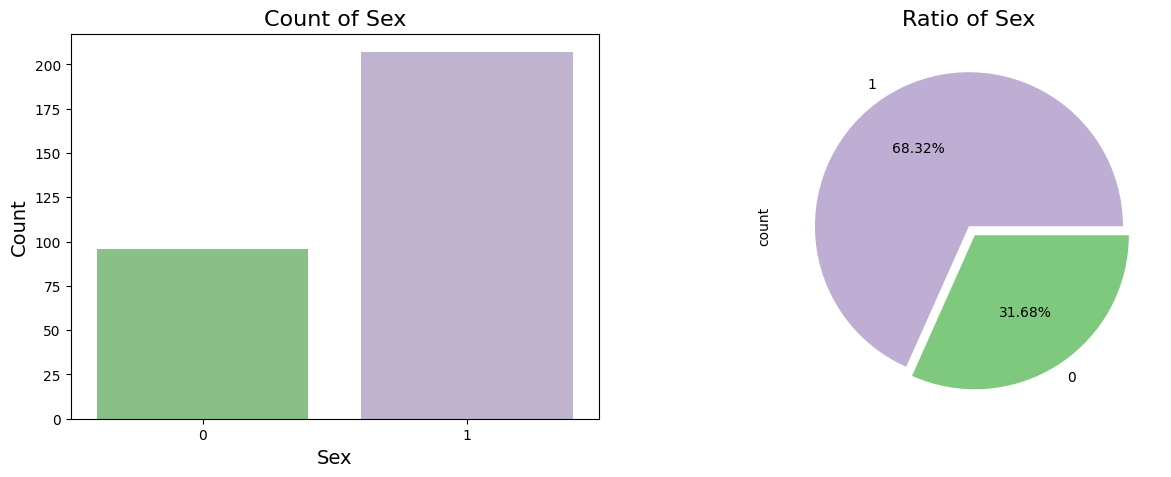

In [ ]:
palette_color = sns.color_palette('Accent')

fig, axs = plt.subplots(1,2, figsize = (15, 5))
ax = sns.countplot(data=df_copy,
                   x=df_copy['sex'],
                   ax = axs[0],
                   palette='Accent');

ax.set_xlabel('Sex', fontsize=14)
ax.set_ylabel('Count', fontsize=14)
axs[0].set_title("Count of Sex", fontsize=16)

ax2 = df_copy['sex'].value_counts().plot.pie(explode=[0,0.07],
                                             colors=[palette_color[1], palette_color[0]],
                                             ax = axs[1],
                                             autopct='%.2f%%');
axs[1].set_title("Ratio of Sex", fontsize=16);

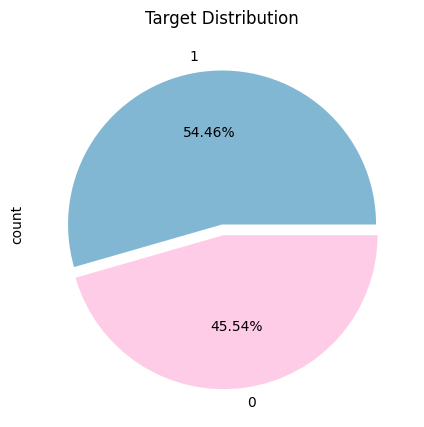

In [ ]:
ax = df_copy['output'].value_counts().plot.pie(explode=[0,0.07],
                                               colors=["#81b7d2", "#ffcce7"],
                                               autopct='%.2f%%',
                                               figsize=(15, 5))
ax.set_title('Target Distribution');

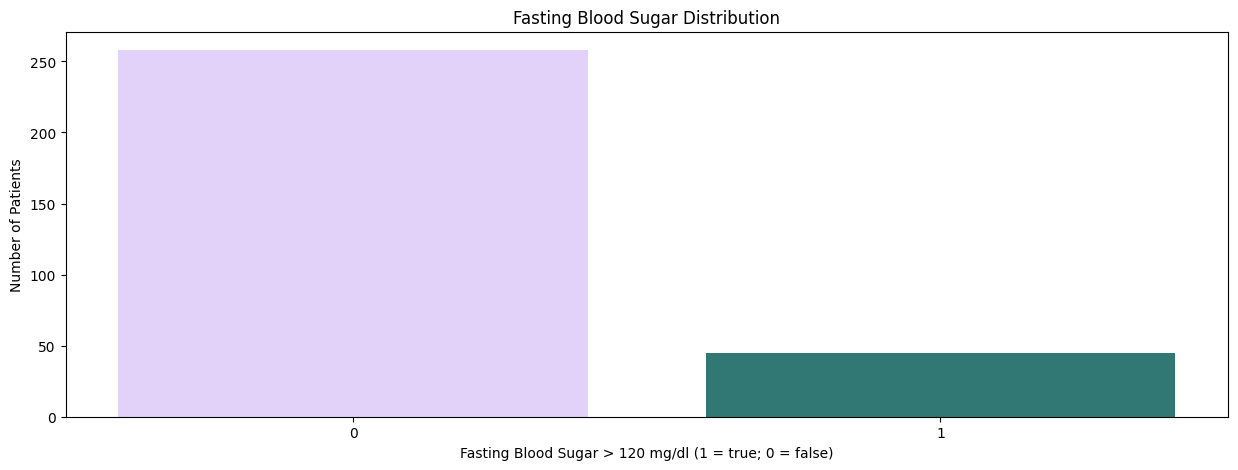

In [ ]:
fbs_count = df['fbs'].value_counts()
plt.figure(figsize=(15,5))
plt.bar(fbs_count.index, fbs_count.values, color=["#E2D1F9", "#317773"])
plt.title('Fasting Blood Sugar Distribution')
plt.xlabel('Fasting Blood Sugar > 120 mg/dl (1 = true; 0 = false)')
plt.ylabel('Number of Patients')
plt.xticks(fbs_count.index)
plt.show()

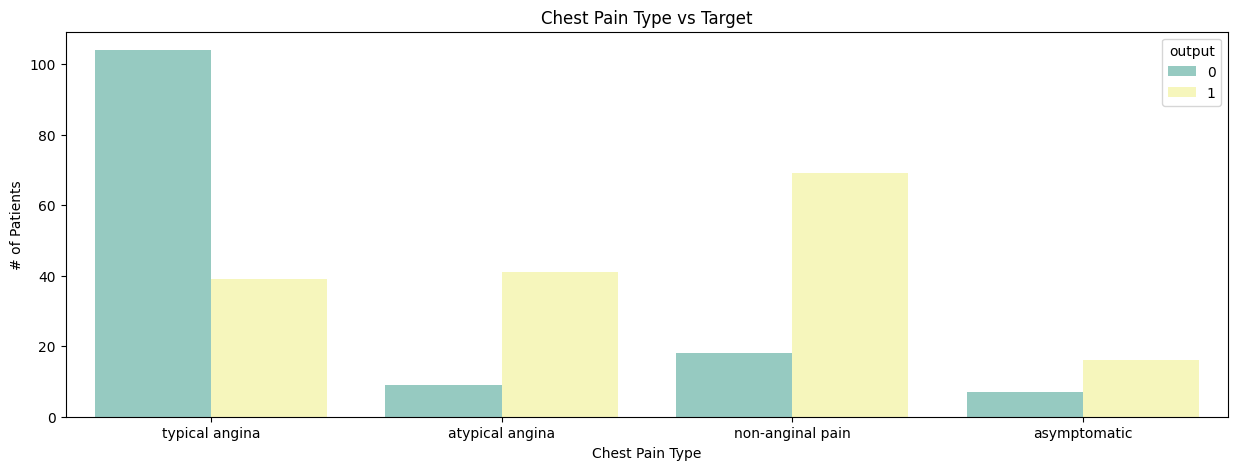

In [ ]:
plt.figure(figsize=(15,5))
sns.countplot(data=df_copy,
              x='cp',
              hue='output',
              palette="Set3")
plt.title('Chest Pain Type vs Target');
plt.xlabel('Chest Pain Type')
plt.ylabel('# of Patients')
plt.xticks(ticks=[0,1,2,3],
           labels=['typical angina', 'atypical angina', 'non-anginal pain', 'asymptomatic'], rotation=0);

### Exporting Correlation Matrix


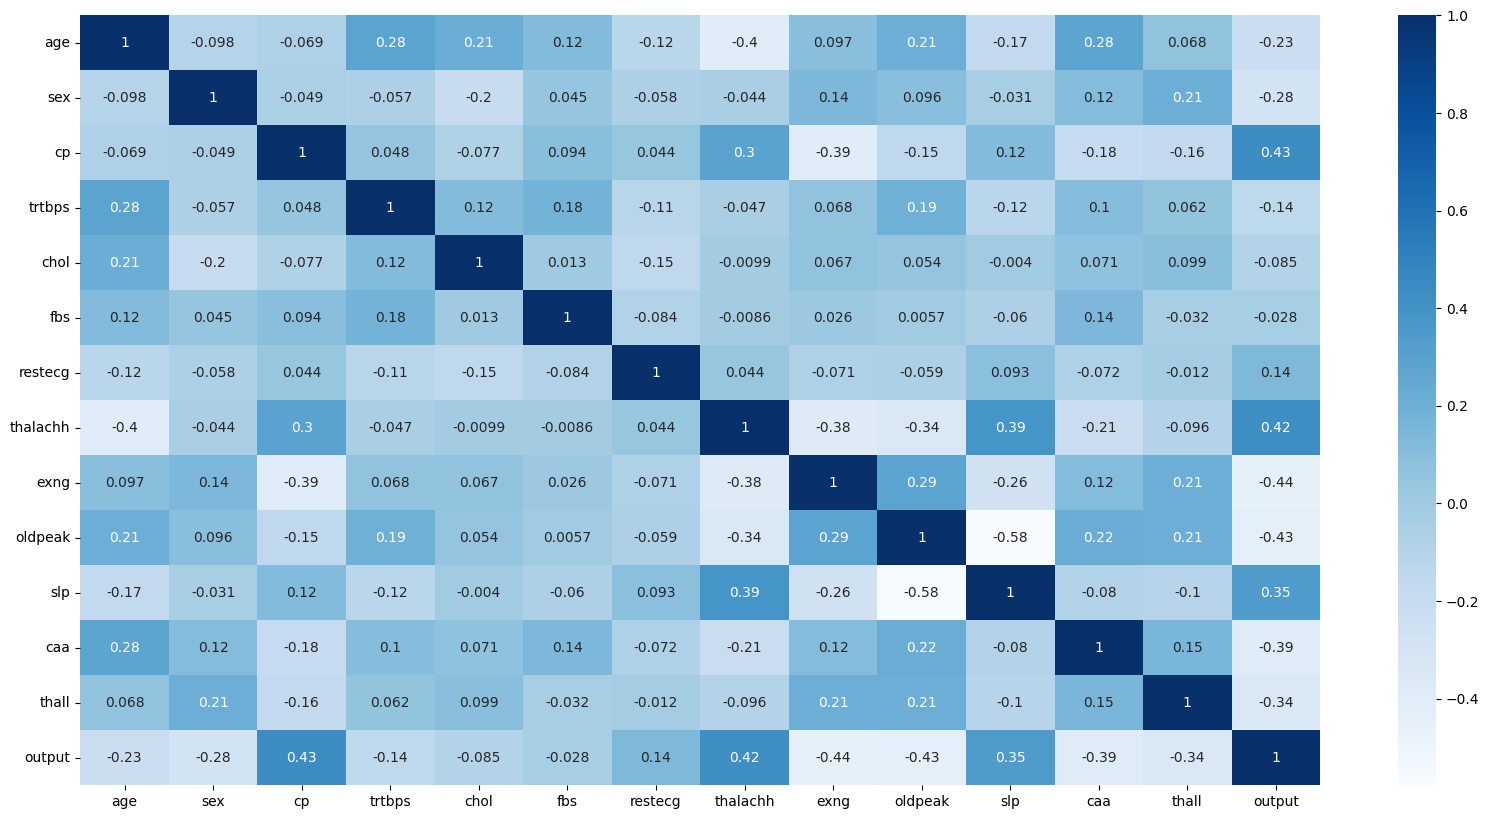

In [ ]:
corr = df.corr()
plt.figure(figsize=(20,10))
sns.heatmap(corr, cmap="Blues", annot=True);

<a id="section-three"></a>

# **Feature Engineering**


<a id="section-four"></a>

## I. Missing Values


In [ ]:
print(pd.concat([df_copy.isnull().sum(), df_copy.isnull().sum()/len(df_copy)*100],
                 keys=['Number of Missing Values', 'Ratio of Missing Values'],
                 axis=1))

          Number of Missing Values  Ratio of Missing Values
age                              0                     0.00
sex                              0                     0.00
cp                               0                     0.00
trtbps                           0                     0.00
chol                             0                     0.00
fbs                              0                     0.00
restecg                          0                     0.00
thalachh                         0                     0.00
exng                             0                     0.00
oldpeak                          0                     0.00
slp                              0                     0.00
caa                              0                     0.00
thall                            0                     0.00
output                           0                     0.00


<a id="section-five"></a>

## II. Outlier Detection and Handling


In [ ]:
def outlier_thresholds(df, col_name, low_quantile=0.25, up_quantile=0.75):
    Q1 = df[col_name].quantile(low_quantile)
    Q3 = df[col_name].quantile(up_quantile)
    IQR = Q3 - Q1
    low_limit = Q1 - 1.5 * IQR
    up_limit = Q3 + 1.5 * IQR
    return low_limit, up_limit

In [ ]:
def check_outlier(dataframe, col_name):
    low_limit, up_limit = outlier_thresholds(dataframe, col_name)
    if dataframe[(dataframe[col_name] > up_limit) | (dataframe[col_name] < low_limit)].any(axis=None):
        return True
    else:
        return False

In [ ]:
for col in num_cols:
    print(col, check_outlier(df_copy, col))

age False
trtbps True
chol True
thalachh True
oldpeak True


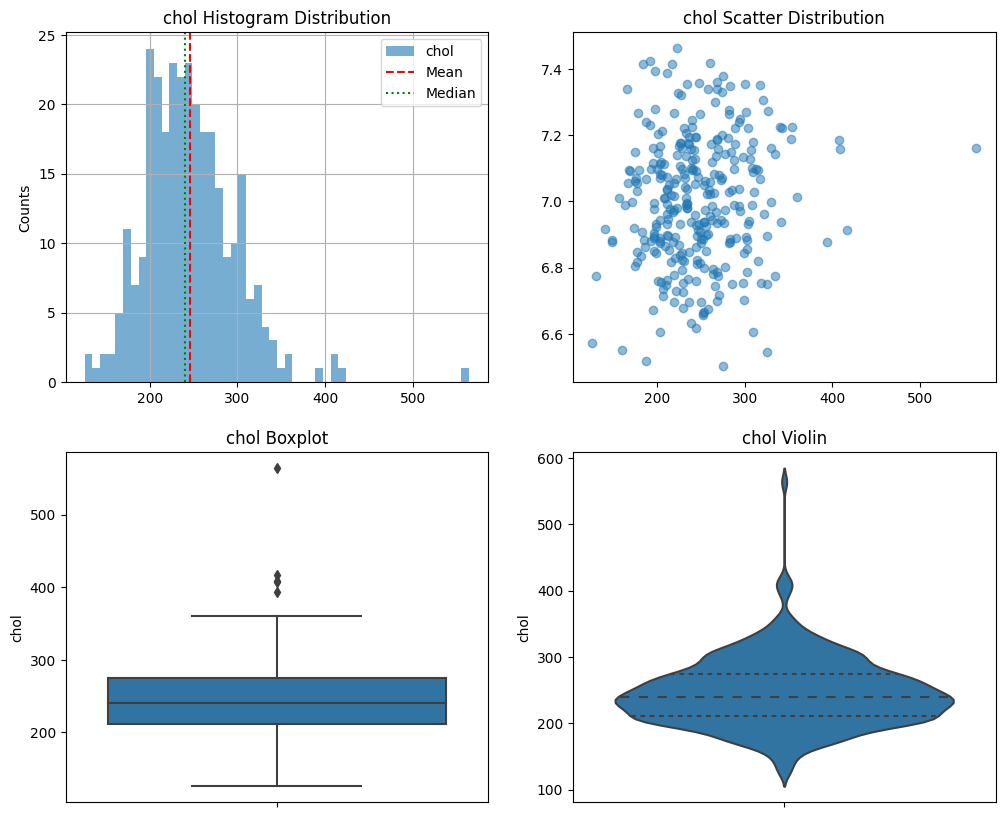

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
df_copy['chol'].hist(bins=50, label='chol', alpha=0.6)
plt.axvline(np.mean(df_copy['chol']), ls='--', c='r', label="Mean")
plt.axvline(np.median(df_copy['chol']), ls=':', c='g', label="Median")
plt.ylabel("Counts")
plt.title("chol Histogram Distribution");
plt.legend()

plt.subplot(2, 2, 2)
plt.scatter(df_copy['chol'], np.random.normal(7, 0.2, size=df_copy.shape[0]), alpha=0.5)
plt.title("chol Scatter Distribution");

plt.subplot(2, 2, 3)
sns.boxplot(y="chol", data=df_copy)
plt.title("chol Boxplot");

plt.subplot(2, 2, 4)
sns.violinplot(y="chol", data=df_copy, inner="quartile", bw=0.2)
plt.title("chol Violin");


In [ ]:
def replace_with_thresholds(dataframe, variable):
    low_limit, up_limit = outlier_thresholds(dataframe, variable)
    dataframe.loc[(dataframe[variable] < low_limit), variable] = low_limit
    dataframe.loc[(dataframe[variable] > up_limit), variable] = up_limit

In [ ]:
for col in num_cols:
    print(col, replace_with_thresholds(df_copy, col))

age None
trtbps None
chol None
thalachh None
oldpeak None


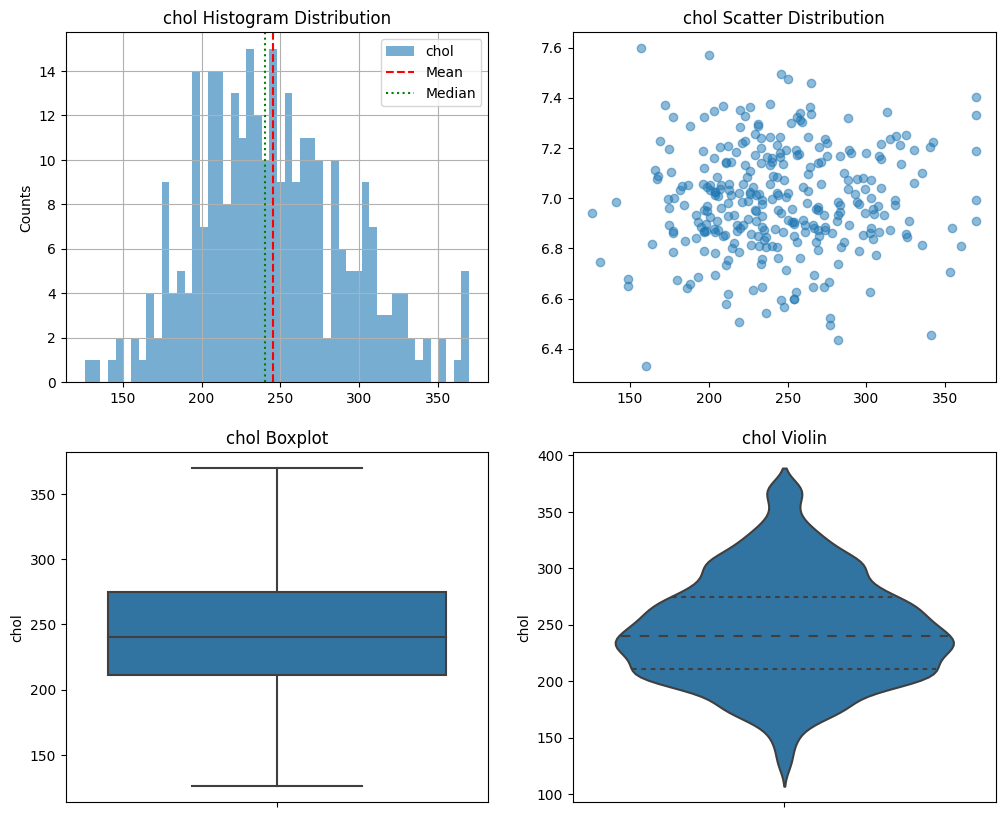

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
df_copy['chol'].hist(bins=50, label='chol', alpha=0.6)
plt.axvline(np.mean(df_copy['chol']), ls='--', c='r', label="Mean")
plt.axvline(np.median(df_copy['chol']), ls=':', c='g', label="Median")
plt.ylabel("Counts")
plt.title("chol Histogram Distribution");
plt.legend()

plt.subplot(2, 2, 2)
plt.scatter(df_copy['chol'], np.random.normal(7, 0.2, size=df_copy.shape[0]), alpha=0.5)
plt.title("chol Scatter Distribution");

plt.subplot(2, 2, 3)
sns.boxplot(y="chol", data=df_copy)
plt.title("chol Boxplot");

plt.subplot(2, 2, 4)
sns.violinplot(y="chol", data=df_copy, inner="quartile", bw=0.2)
plt.title("chol Violin");

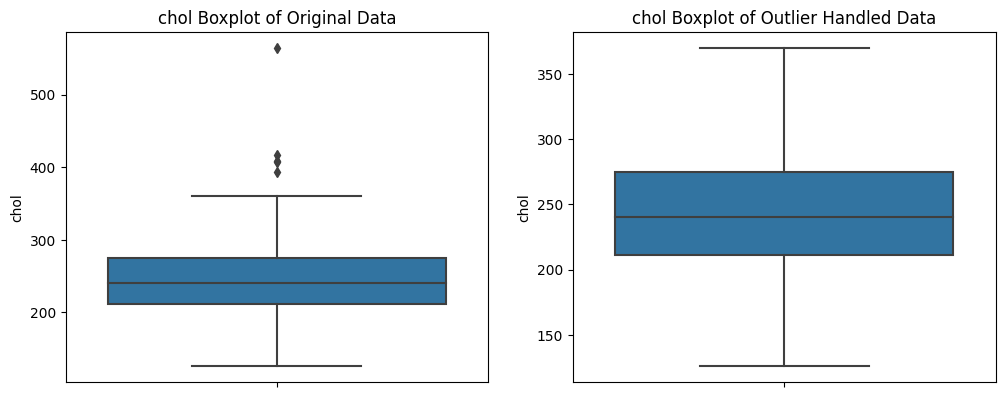

In [ ]:
plt.figure(figsize=(12, 10))

plt.subplot(2, 2, 1)
sns.boxplot(y="chol", data=df)
plt.title("chol Boxplot of Original Data");

plt.subplot(2, 2, 2)
sns.boxplot(y="chol", data=df_copy)
plt.title("chol Boxplot of Outlier Handled Data");

<a id="section-six"></a>

## III. Feature Extraction


In [ ]:
df_copy['Age_CAT'] = pd.cut(x=df_copy['age'],
                            bins=[20, 40, 60, df_copy['age'].max()],
                            labels=["Adult", "Middle_Age_Adult", "Senior_Adult"])

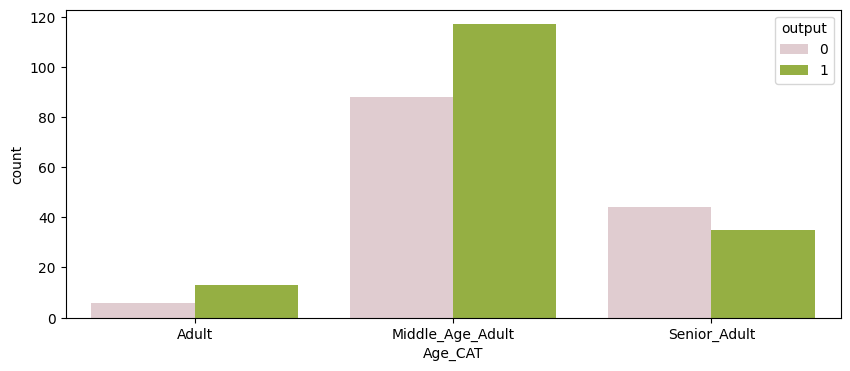

In [ ]:
plt.figure(figsize=(10,4))
sns.countplot(data=df_copy, x='Age_CAT',
              hue='output',
              order=["Adult", "Middle_Age_Adult", "Senior_Adult"],
              palette=["#E3C9CEFF", "#9FC131FF"])
plt.show()

In [ ]:
cat_cols.append('Age_CAT')
cat_cols

['sex',
 'cp',
 'fbs',
 'restecg',
 'exng',
 'slp',
 'caa',
 'thall',
 'output',
 'Age_CAT']

<a id="section-seven"></a>

## IV. Encoding and Scaling


In [ ]:
def one_hot_encoder(dataframe, categorical_col, drop_first=True):
    dataframe = pd.get_dummies(dataframe, columns=categorical_col, drop_first=drop_first)
    return dataframe

ohe_cols = [col for col in df_copy.columns if 12 >= df_copy[col].nunique() > 2]
df_copy = one_hot_encoder(df_copy, ohe_cols, drop_first=True)

In [ ]:
scaler = StandardScaler()
df_copy[num_cols] = scaler.fit_transform(df_copy[num_cols])

<a id="section-eight"></a>

# **Model Training**


In [ ]:
y = df_copy["output"]
X = df_copy.drop("output", axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)

In [ ]:
print('Shape of x_train is {}'.format(X_train.shape))
print('Shape of x_test is {}'.format(X_test.shape))
print('Shape of y_train is {}'.format(y_train.shape))
print('Shape of y_test is {}'.format(y_test.shape))

Shape of x_train is (242, 24)
Shape of x_test is (61, 24)
Shape of y_train is (242,)
Shape of y_test is (61,)


In [ ]:
models = [('LR', LogisticRegression(random_state=17, solver='lbfgs', max_iter=3000)),
          ('CART', DecisionTreeClassifier(random_state=17)),
          ('RF', RandomForestClassifier(random_state=17)),
          ('XGB', XGBClassifier(random_state=17, eval_metric='logloss')),
          ('LightGBM', LGBMClassifier(random_state=17, verbose=-1)),
          ('CatBoost', CatBoostClassifier(random_state=17, verbose=False))]

In [ ]:
for name, model in models:
    cv_results = cross_validate(model, X, y, cv=10, scoring=['accuracy', 'f1', 'roc_auc', 'precision', 'recall'])
    print(f'########## {name} ##########')
    print(f'Accuracy: {round(cv_results["test_accuracy"].mean(), 4)}')
    print(f'Auc: {round(cv_results["test_roc_auc"].mean(), 4)}')
    print(f'Recall: {round(cv_results["test_recall"].mean(), 4)}')
    print(f'Precision: {round(cv_results["test_precision"].mean(), 4)}')
    print(f'F1: {round(cv_results["test_f1"].mean(), 4)}')

########## LR ##########
Accuracy: 0.858
Auc: 0.9218
Recall: 0.8901
Precision: 0.8594
F1: 0.8721
########## CART ##########
Accuracy: 0.7396
Auc: 0.7382
Recall: 0.7643
Precision: 0.766
F1: 0.7602
########## RF ##########
Accuracy: 0.7855
Auc: 0.8942
Recall: 0.8055
Precision: 0.8048
F1: 0.8024
########## XGB ##########
Accuracy: 0.7883
Auc: 0.8872
Recall: 0.8294
Precision: 0.7971
F1: 0.8088
########## LightGBM ##########
Accuracy: 0.8014
Auc: 0.8921
Recall: 0.8474
Precision: 0.8068
F1: 0.821
########## CatBoost ##########
Accuracy: 0.8147
Auc: 0.905
Recall: 0.8415
Precision: 0.8287
F1: 0.831


## **Further Steps:**

**1. Detailed Analysis of Variable Connections:**

- Conduct univariate analysis to understand individual variable distributions.
- Perform bivariate analysis to explore relationships between pairs of variables.
- Utilize multivariate analysis techniques to uncover complex interactions among multiple variables.

**2. Feature Engineering:**

- Use domain knowledge to create new features that may improve model performance.
- Experiment with polynomial features, interaction terms, or aggregation of existing variables.

**3. Model Selection:**

- Experiment with different machine learning models, including:
  - Decision Trees
  - Random Forests
  - Gradient Boosting Machines (e.g., LightGBM, CatBoost, XGBoost)
  - Support Vector Machines
  - Neural Networks

* Compare their performances using metrics relevant to the problem (accuracy, F1 score, AUC, etc.).

**4. Hyperparameter Tuning:**

- Implement GridSearch and RandomSearch for systematic hyperparameter tuning.
- Consider using more advanced techniques like Bayesian Optimization or Optuna for more efficient searches.
- Assess the impact of hyperparameter changes on model performance through cross-validation.

**5. Feature Importance Evaluation:**

- Utilize techniques like SHAP values or feature importance scores from tree-based models to evaluate the importance of features.
- Based on the importance levels, decide whether to remove or retain certain features in the final model.

**6. Model Evaluation and Iteration:**

- Evaluate the final model using a hold-out test set or cross-validation.
- Iterate on feature engineering and hyperparameter tuning based on evaluation results to continually improve the model.

**7. Documentation and Reporting:**

- Document the methodologies, experiments, and results to ensure reproducibility.
- Prepare a comprehensive report summarizing findings, methodologies, and recommendations for stakeholders.

This structured approach will help ensure thorough analysis and optimization throughout the modeling process.
